<a href="https://colab.research.google.com/github/edanielson-star/Taylor-Rule-NN-Approx/blob/main/TaylorRule5Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**From a series of application of modern interpolation methods for economics: written by [Mahdi E Kahou](https://sites.google.com/site/mahdiebrahimikahou/about-me)**


Note: This notebook should take at most **50 seconds** to run. From `Runtime` choose `Run all` to run this code.

In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib import cm

In [29]:
fontsize= 14
ticksize = 14
figsize = (10, 4.5)
params = {'font.family':'serif',
    "figure.figsize":figsize,
    'figure.dpi': 80,
    'figure.edgecolor': 'k',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': ticksize,
    'ytick.labelsize': ticksize
}
plt.rcParams.update(params)

In [30]:
class Grid_data:
    def __init__(self,
                 max_T = 32,
                 batch_size = 8,
                 mesh_step = 0.3):


        self.max_T = max_T
        self.mesh_step = mesh_step
        self.batch_size = batch_size

        self.time_range = torch.arange(start = 0.0, end = self.max_T , step = self.mesh_step)
        dim = self.time_range.shape[0]
        self.grid = self.time_range.reshape([dim,1])

In [31]:
class Data_label(Dataset):

    def __init__(self,data):
        self.time = data
        self.n_samples = self.time.shape[0]

    def __getitem__(self,index):
            return self.time[index]

    def __len__(self):
        return self.n_samples

In [32]:
train_data = Grid_data().grid
train_labeled = Data_label(train_data)
train = DataLoader(dataset = train_labeled, batch_size = 8 , shuffle = True )

In [33]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

## Defining the differential operator (backward differencing):
$\begin{align}
\frac{d}{dt} f(t) ≈ \frac{f(t)-f(t-\epsilon)}{\epsilon}
\end{align}$

In [34]:
def derivative_back(model,t): #backward differencing
    epsilon = 1.0e-8
    sqrt_eps = np.sqrt(epsilon)
    return (model(t)- model(t-sqrt_eps))/sqrt_eps

## Setting up the model parameters

In [35]:
# 1. Parameter Calibration (Benhabib, Schmitt-Grohé, and Uribe 2001)
A = 2              # Active Taylor Rule coefficient
r = 0.018 / 4        # Steady-state real rate (quarterly)
pi_star = 0.042 / 4  # Central bank target inflation
R_star = r + pi_star # Target nominal interest rate

# Structural parameters
omega = -1.0
eta = -6.0
v = 1.0
alpha = 0.7
gamma = 50.0
x = 0.5

In [36]:
class NN_macro(nn.Module):
    def __init__(self, dim_hidden=128, layers=5):
        super().__init__()
        torch.manual_seed(123)
        module = []
        module.append(nn.Linear(1, dim_hidden))
        module.append(nn.Tanh())

        for i in range(layers-1):
            module.append(nn.Linear(dim_hidden, dim_hidden))
            module.append(nn.Tanh())

        module.append(nn.Linear(dim_hidden, 2))
        self.q = nn.Sequential(*module)
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, x):
        out = self.q(x)
        lam = self.softplus(out[:, [0]]) + 1e-5 # lambda must be strictly positive
        pi = out[:, [1]] # pi can be negative
        return torch.cat((lam, pi), dim=1)

In [37]:
def R_torch(pi):
    return R_star * torch.exp((A / R_star) * (pi - pi_star))

def G_macro(model, t):
    out = model(t)
    lam = out[:, [0]]
    pi = out[:, [1]]

    # d(lambda)/dt
    dlam = lam * (r + pi - R_torch(pi))

    # d(pi)/dt
    term1 = r * (pi - pi_star)
    term2 = -((1 + eta) / gamma) * (lam ** (omega / (omega - 1))) * (x ** (1 / (1 - omega)))
    term3 = (eta / (gamma * alpha)) * (lam ** ((1 + v) / (alpha * (omega - 1)))) * (x ** ((1 + v) / (alpha * (1 - omega))))
    dpi = term1 + term2 + term3

    return torch.stack((dlam, dpi), 1).squeeze()

In [38]:
q_hat_macro = NN_macro()
learning_rate = 1e-3
optimizer_macro = torch.optim.Adam(q_hat_macro.parameters(), lr=learning_rate)
scheduler_macro = torch.optim.lr_scheduler.StepLR(optimizer_macro, step_size=100, gamma=0.8)

num_epochs_macro = 1000
pi_0 = 0.011 # Initial condition for pi

for epoch in range(num_epochs_macro):
    for i, time in enumerate(train):
        time_zero = torch.zeros([1,1])

        res_ode = derivative_back(q_hat_macro, time) - G_macro(q_hat_macro, time)
        # Initial condition on pi (index 1), lambda_0 is learned
        res_init = q_hat_macro(time_zero)[:, [1]] - pi_0

        loss_ode = res_ode.pow(2).mean()
        loss_init = res_init.pow(2).mean()

        # Greatly increase the weight of the initial condition so it isn't overpowered
        loss = loss_ode + 100.0 * loss_init

        optimizer_macro.zero_grad()
        loss.backward()

        # Optional: clip gradients to prevent the exponential Taylor rule from exploding the weights
        torch.nn.utils.clip_grad_norm_(q_hat_macro.parameters(), max_norm=1.0)

        optimizer_macro.step()

    scheduler_macro.step()
    if epoch == 0:
         print('epoch , loss , loss_ode , loss_initial , lr_rate')
    if epoch % 250 == 0:
         print(f"{epoch} , {loss.item():.2e} , {loss_ode.item():.2e} , {loss_init.item():.2e} , {get_lr(optimizer_macro):.2e}")

epoch , loss , loss_ode , loss_initial , lr_rate
0 , 1.43e-01 , 1.40e-03 , 1.42e-03 , 1.00e-03
250 , 2.32e-06 , 5.66e-08 , 2.27e-08 , 6.40e-04
500 , 2.07e-07 , 7.21e-08 , 1.35e-09 , 3.28e-04
750 , 7.73e-07 , 3.71e-07 , 4.02e-09 , 2.10e-04


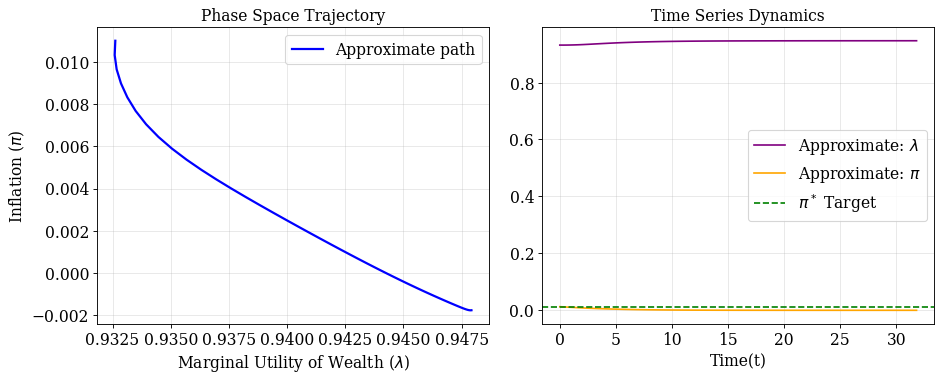

In [39]:
time_test_macro = Grid_data().grid
lam_hat_path = q_hat_macro(time_test_macro)[:, [0]].detach().numpy()
pi_hat_path = q_hat_macro(time_test_macro)[:, [1]].detach().numpy()
time_np = time_test_macro.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lam_hat_path, pi_hat_path, label="Approximate path", color='blue', linewidth=2)
plt.ylabel(r"Inflation ($\pi$)")
plt.xlabel(r"Marginal Utility of Wealth ($\lambda$)")
plt.title("Phase Space Trajectory")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time_np, lam_hat_path, label=r"Approximate: $\lambda$", color='purple')
plt.plot(time_np, pi_hat_path, label=r"Approximate: $\pi$", color='orange')
plt.axhline(y=pi_star, color='g', linestyle='--', label=r"$\pi^*$ Target")
plt.xlabel("Time(t)")
plt.title("Time Series Dynamics")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

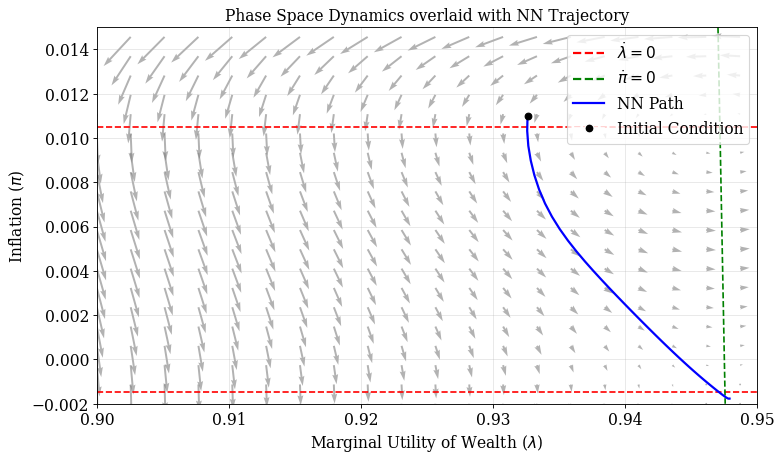

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Numpy equivalent of the vector field
def vector_field_np(lam, pi):
    lam = np.maximum(lam, 1e-5)
    dlam = lam * (r + pi - R_star * np.exp((A / R_star) * (pi - pi_star)))
    term1 = r * (pi - pi_star)
    term2 = -((1 + eta) / gamma) * (lam ** (omega / (omega - 1))) * (x ** (1 / (1 - omega)))
    term3 = (eta / (gamma * alpha)) * (lam ** ((1 + v) / (alpha * (omega - 1)))) * (x ** ((1 + v) / (alpha * (1 - omega))))
    dpi = term1 + term2 + term3
    return dlam, dpi

# Create a grid covering the trajectory bounds
L_min, L_max = 0.90, 0.95
P_min, P_max = -0.002, 0.015

L_grid, P_grid = np.meshgrid(
    np.linspace(L_min, L_max, 40),
    np.linspace(P_min, P_max, 40)
)

# Calculate vector field
dL, dP = vector_field_np(L_grid, P_grid)

plt.figure(figsize=(10, 6))

# Quiver plot for the vector field
plt.quiver(L_grid[::2, ::2], P_grid[::2, ::2], dL[::2, ::2], dP[::2, ::2], color='gray', alpha=0.6)

# Plot nullclines
plt.contour(L_grid, P_grid, dL, levels=[0], colors='r', linestyles='--')
plt.contour(L_grid, P_grid, dP, levels=[0], colors='g', linestyles='--')

# Plot the NN learned trajectory
plt.plot(lam_hat_path, pi_hat_path, color='blue', linewidth=2, label='NN Approximate Path')
plt.scatter(lam_hat_path[0], pi_hat_path[0], color='black', zorder=5, label='Start')

plt.ylabel(r"Inflation ($\pi$)")
plt.xlabel(r"Marginal Utility of Wealth ($\lambda$)")
plt.title("Phase Space Dynamics overlaid with NN Trajectory")

# Custom legend
custom_lines = [Line2D([0], [0], color='r', linestyle='--', lw=2),
                Line2D([0], [0], color='g', linestyle='--', lw=2),
                Line2D([0], [0], color='blue', lw=2),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8)]
plt.legend(custom_lines, [r'$\dot{\lambda}=0$', r'$\dot{\pi}=0$', 'NN Path', 'Initial Condition'], loc='best')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()